merged: 115 Galaxien
clean:  102 Galaxien

Spalten clean: ['galaxy', 'Vout', 'Verr', 'n_points', 'Galaxy', 'T', 'D', 'e_D', 'f_D', 'Inc', 'e_Inc', 'L36', 'e_L36', 'Reff', 'SBeff', 'Rdisk', 'SBdisk', 'MHI', 'RHI', 'Vflat', 'e_Vflat', 'Q', 'Ref', 'Mstar', 'Mgas', 'Mbar', 'logV_flat', 'logV_out', 'logM', 'res_flat', 'res_out']

=== BTFR Ergebnisse ===
n Galaxien:    102
Steigung Vflat: 3.547
Steigung Vout:  3.549
RMS Vflat:     0.2220 dex
RMS Vout:      0.2198 dex
Reduktion:     1.0%
Korrelation Verbesserung vs logV: r=0.092, p=0.3585

Hochbeschleunigt (n=51):
  RMS Vflat: 0.2198
  RMS Vout:  0.2162
  Reduktion: 1.6%

Niedrigbeschleunigt (n=51):
  RMS Vflat: 0.2225
  RMS Vout:  0.2218
  Reduktion: 0.3%


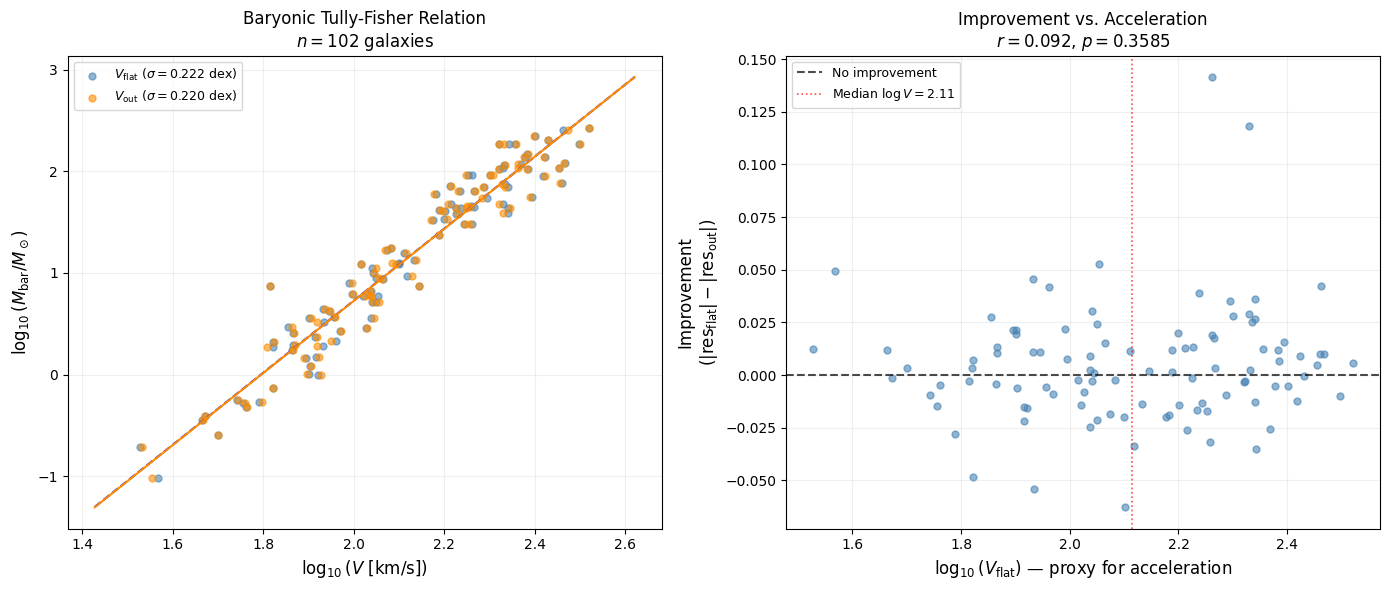

Saved: btfr_comparison.png
Saved: clean_btfr_final.csv


In [10]:
# ============================================================
# BTFR Final Analysis — Complete Recomputation
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import os

# ============================================================
# Schritt 1: Daten laden
# Dateien manuell in /content hochgeladen
# ============================================================

merged = pd.read_csv('/content/merged_btfr.csv')
clean  = pd.read_csv('/content/btfr_final.csv')

print(f'merged: {len(merged)} Galaxien')
print(f'clean:  {len(clean)} Galaxien')
print(f'\nSpalten clean: {clean.columns.tolist()}')

# ============================================================
# Schritt 2: Log-Größen berechnen falls nicht vorhanden
# ============================================================

if 'logV_flat' not in clean.columns:
    clean['logV_flat'] = np.log10(clean['Vflat'])
if 'logV_out' not in clean.columns:
    clean['logV_out']  = np.log10(clean['Vout'])
if 'logM' not in clean.columns:
    clean['logM'] = np.log10(clean['Mbar'] * 1e9)

# ============================================================
# Schritt 3: BTFR-Fits
# ============================================================

def compute_residuals(df, vcol):
    sl, ic, r, p, se = stats.linregress(
        df[vcol], df['logM'])
    res = df['logM'] - (sl * df[vcol] + ic)
    return res, sl, ic, r, p

clean['res_flat'], sl_f, ic_f, r_f, p_f = \
    compute_residuals(clean, 'logV_flat')
clean['res_out'],  sl_o, ic_o, r_o, p_o = \
    compute_residuals(clean, 'logV_out')

rms_flat = np.std(clean['res_flat'])
rms_out  = np.std(clean['res_out'])
red_pct  = (rms_flat - rms_out) / rms_flat * 100

print(f'\n=== BTFR Ergebnisse ===')
print(f'n Galaxien:    {len(clean)}')
print(f'Steigung Vflat: {sl_f:.3f}')
print(f'Steigung Vout:  {sl_o:.3f}')
print(f'RMS Vflat:     {rms_flat:.4f} dex')
print(f'RMS Vout:      {rms_out:.4f} dex')
print(f'Reduktion:     {red_pct:.1f}%')

improvement = (clean['res_flat'].abs() -
               clean['res_out'].abs())
r_imp, p_imp = stats.pearsonr(
    clean['logV_flat'], improvement)
print(f'Korrelation Verbesserung vs logV: '
      f'r={r_imp:.3f}, p={p_imp:.4f}')

# Nach Beschleunigungsregime
median_logV = clean['logV_flat'].median()
for label, sub in [
    ('Hochbeschleunigt',
     clean[clean['logV_flat'] >= median_logV]),
    ('Niedrigbeschleunigt',
     clean[clean['logV_flat'] <  median_logV])
]:
    rf = np.std(sub['res_flat'])
    ro = np.std(sub['res_out'])
    print(f'\n{label} (n={len(sub)}):')
    print(f'  RMS Vflat: {rf:.4f}')
    print(f'  RMS Vout:  {ro:.4f}')
    print(f'  Reduktion: {(rf-ro)/rf*100:.1f}%')

# ============================================================
# Schritt 4: Abbildung
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: BTFR Vergleich
ax = axes[0]
ax.scatter(clean['logV_flat'], clean['logM'],
           s=25, alpha=0.6, color='steelblue',
           label=f'$V_\\mathrm{{flat}}$ '
                 f'($\\sigma={rms_flat:.3f}$ dex)')
ax.scatter(clean['logV_out'], clean['logM'],
           s=25, alpha=0.6, color='darkorange',
           label=f'$V_\\mathrm{{out}}$ '
                 f'($\\sigma={rms_out:.3f}$ dex)')

x_range = np.linspace(
    clean['logV_flat'].min() - 0.1,
    clean['logV_flat'].max() + 0.1, 100)
ax.plot(x_range, sl_f*x_range + ic_f,
        'b--', linewidth=1.5)
ax.plot(x_range, sl_o*x_range + ic_o,
        '-', color='darkorange', linewidth=1.5)

ax.set_xlabel(
    '$\\log_{10}(V\\ [\\mathrm{km/s}])$',
    fontsize=12)
ax.set_ylabel(
    '$\\log_{10}(M_\\mathrm{bar}/M_\\odot)$',
    fontsize=12)
ax.set_title(
    f'Baryonic Tully-Fisher Relation\n'
    f'$n = {len(clean)}$ galaxies',
    fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

# Panel B: Verbesserung vs Beschleunigung
ax = axes[1]
ax.scatter(clean['logV_flat'], improvement,
           s=25, alpha=0.6, color='steelblue')
ax.axhline(0, linestyle='--', color='black',
           linewidth=1.5, alpha=0.7,
           label='No improvement')
ax.axvline(median_logV, linestyle=':',
           color='red', linewidth=1.2, alpha=0.7,
           label=f'Median $\\log V = {median_logV:.2f}$')

ax.set_xlabel(
    '$\\log_{10}(V_\\mathrm{flat})$ '
    '— proxy for acceleration',
    fontsize=12)
ax.set_ylabel(
    'Improvement\n'
    '($|\\mathrm{res}_\\mathrm{flat}| - '
    '|\\mathrm{res}_\\mathrm{out}|$)',
    fontsize=12)
ax.set_title(
    f'Improvement vs. Acceleration\n'
    f'$r = {r_imp:.3f}$, $p = {p_imp:.4f}$',
    fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('/content/btfr_comparison.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: btfr_comparison.png')

# ============================================================
# Schritt 5: Ergebnisse speichern
# ============================================================

clean.to_csv('/content/clean_btfr_final.csv', index=False)
print('Saved: clean_btfr_final.csv')